# A1

In [2]:
import pandas as pd

def LabelEncoding(df, column):
    unique_values = df[column].unique()

    label_dict = {}
    for i, value in enumerate(unique_values):
        label_dict[value] = i

    encoded_df = pd.DataFrame()
    encoded_df[column + "_Label"] = df[column].map(label_dict)

    return encoded_df


def OneHotEncoding(df, column):
    unique_values = df[column].unique()

    encoded_df = pd.DataFrame(index=df.index)

    for value in unique_values:
        encoded_df[str(value)] = (df[column] == value).astype(int)

    return encoded_df


df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)



label_encoded = LabelEncoding(df, "Education")
one_hot_encoded = OneHotEncoding(df, "Marital_Status")

print(label_encoded)
print(one_hot_encoded)

      Education_Label
0                   0
1                   0
2                   0
3                   0
4                   1
...               ...
2235                0
2236                1
2237                0
2238                2
2239                1

[2240 rows x 1 columns]
      Single  Together  Married  Divorced  Widow  Alone  Absurd  YOLO
0          1         0        0         0      0      0       0     0
1          1         0        0         0      0      0       0     0
2          0         1        0         0      0      0       0     0
3          0         1        0         0      0      0       0     0
4          0         0        1         0      0      0       0     0
...      ...       ...      ...       ...    ...    ...     ...   ...
2235       0         0        1         0      0      0       0     0
2236       0         1        0         0      0      0       0     0
2237       0         0        0         1      0      0       0     0
2238       

In [3]:
def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both points must have the same number of dimensions.")

    distance = 0

    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p

    distance = distance ** (1 / p)

    if p == 1:
        print("It is Manhattan Distance.")
    elif p == 2:
        print("It is Euclidean Distance.")

    return distance

X = [2, 3, 4]
Y = [5, 7, 1]

print("Distance =", MinkowskiDist(X, Y, 1))
print("Distance =", MinkowskiDist(X, Y, 2))
print("Distance =", MinkowskiDist(X, Y, 3))

It is Manhattan Distance.
Distance = 10.0
It is Euclidean Distance.
Distance = 5.830951894845301
Distance = 4.904868131524016


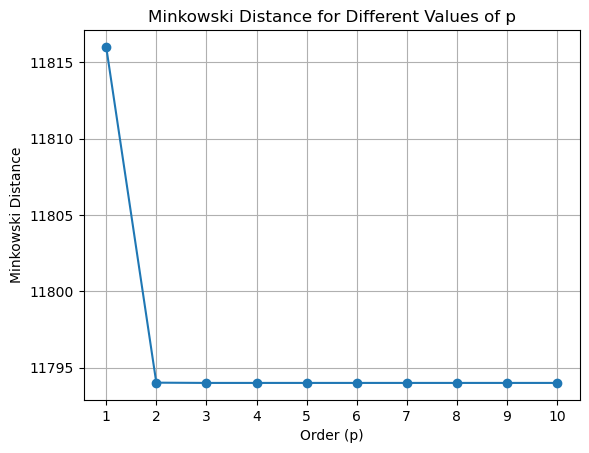

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both feature vectors must have the same dimensions.")

    distance = 0

    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p

    distance = distance ** (1 / p)

    return distance


df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

features = ["Income", "Kidhome", "Teenhome", "Recency"]

X = df.loc[0, features].values
Y = df.loc[1, features].values

p_values = []
distances = []

for p in range(1, 11):
    distance = MinkowskiDist(X, Y, p)
    p_values.append(p)
    distances.append(distance)

plt.plot(p_values, distances, marker='o')
plt.title("Minkowski Distance for Different Values of p")
plt.xlabel("Order (p)")
plt.ylabel("Minkowski Distance")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [1]:
import pandas as pd
from scipy.spatial.distance import minkowski

def MinkowskiDist(X, Y, p):
    distance = 0
    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p
    return distance ** (1 / p)

df = pd.read_excel(r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx", sheet_name="marketing_campaign")

numeric_df = df.select_dtypes(include="number")

X = numeric_df.iloc[0, :2].values
Y = numeric_df.iloc[1, :2].values

print("Vector X:", X)
print("Vector Y:", Y)

p = 3
own_distance = MinkowskiDist(X, Y, p)
scipy_distance = minkowski(X, Y, p)

print("\np =", p)
print("Own Function :", own_distance)
print("SciPy        :", scipy_distance)
print("Difference   :", abs(own_distance - scipy_distance))

Vector X: [5524. 1957.]
Vector Y: [2174. 1954.]

p = 3
Own Function : 3350.000000801959
SciPy        : 3350.000000801959
Difference   : 0.0


In [7]:
import numpy as np

def DotProduct(A, B):
    if len(A) != len(B):
        raise ValueError("Vectors must have the same length.")

    dot = 0
    for i in range(len(A)):
        dot += A[i] * B[i]

    return dot


def EuclideanNorm(A):
    norm = 0
    for i in range(len(A)):
        norm += A[i] ** 2

    return norm ** 0.5


A = np.array([2, 4, 6, 8])
B = np.array([1, 3, 5, 7])

manual_dot = DotProduct(A, B)
manual_norm_A = EuclideanNorm(A)
manual_norm_B = EuclideanNorm(B)

numpy_dot = np.dot(A, B)
numpy_norm_A = np.linalg.norm(A)
numpy_norm_B = np.linalg.norm(B)

print("Manual Dot Product :", manual_dot)
print("NumPy Dot Product  :", numpy_dot)

print("\nManual Euclidean Norm of A :", manual_norm_A)
print("NumPy Euclidean Norm of A  :", numpy_norm_A)

print("\nManual Euclidean Norm of B :", manual_norm_B)
print("NumPy Euclidean Norm of B  :", numpy_norm_B)

Manual Dot Product : 100
NumPy Dot Product  : 100

Manual Euclidean Norm of A : 10.954451150103322
NumPy Euclidean Norm of A  : 10.954451150103322

Manual Euclidean Norm of B : 9.16515138991168
NumPy Euclidean Norm of B  : 9.16515138991168


In [8]:
import pandas as pd

def Mean(data):
    total = 0

    for value in data:
        total += value

    return total / len(data)

def Variance(data):
    mean = Mean(data)

    variance = 0

    for value in data:
        variance += (value - mean) ** 2

    return variance / len(data)      # Population Variance


def StandardDeviation(data):
    variance = Variance(data)

    return variance ** 0.5


# for every feature (column) in the dataset
def FeatureStatistics(df):
    statistics = pd.DataFrame(
        columns=["Feature", "Mean", "Variance", "Standard Deviation"]
    )

    for column in df.columns:
        statistics.loc[len(statistics)] = [
            column,
            Mean(df[column]),
            Variance(df[column]),
            StandardDeviation(df[column])
        ]

    return statistics

df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

numeric_df = df.select_dtypes(include="number")
result = FeatureStatistics(numeric_df)
print(result)

                Feature         Mean      Variance  Standard Deviation
0                    ID  5592.159821  1.053611e+07         3245.937415
1            Year_Birth  1968.805804  1.435538e+02           11.981394
2                Income          NaN           NaN                 NaN
3               Kidhome     0.444196  2.897431e-01            0.538278
4              Teenhome     0.506250  2.963895e-01            0.544417
5               Recency    49.109375  8.384492e+02           28.955987
6              MntWines   303.935714  1.132472e+05          336.522251
7             MntFruits    26.302232  1.581220e+03           39.764555
8       MntMeatProducts   166.950000  5.092469e+04          225.664984
9       MntFishProducts    37.525446  2.982993e+03           54.616784
10     MntSweetProducts    27.062946  1.703319e+03           41.271283
11         MntGoldProds    44.021875  2.720227e+03           52.155793
12    NumDealsPurchases     2.325000  3.731875e+00            1.931806
13    

In [10]:
import pandas as pd
import numpy as np

def Mean(data):
    total = 0

    for value in data:
        total += value

    return total / len(data)


def Variance(data):
    mean = Mean(data)

    variance = 0

    for value in data:
        variance += (value - mean) ** 2

    return variance / len(data)

def StandardDeviation(data):
    return Variance(data) ** 0.5


def ManualStatistics(df):
    means = []
    stds = []

    for column in df.columns:
        means.append(Mean(df[column]))
        stds.append(StandardDeviation(df[column]))

    return means, stds


df = pd.read_excel(
    r"C:\Users\ivysa\Downloads\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

numeric_df = df.select_dtypes(include="number")

manual_mean, manual_std = ManualStatistics(numeric_df)

# NumPy calculations (column-wise)
numpy_mean = np.mean(numeric_df, axis=0)
numpy_std = np.std(numeric_df, axis=0)

comparison = pd.DataFrame({
    #"Feature": numeric_df.columns,
    "Manual Mean": manual_mean,
    "NumPy Mean": numpy_mean,
    "Manual Std Dev": manual_std,
    "NumPy Std Dev": numpy_std
})

print(comparison)

                     Manual Mean    NumPy Mean  Manual Std Dev  NumPy Std Dev
ID                   5592.159821   5592.159821     3245.937415    3245.937415
Year_Birth           1968.805804   1968.805804       11.981394      11.981394
Income                       NaN  52247.251354             NaN   25167.396174
Kidhome                 0.444196      0.444196        0.538278       0.538278
Teenhome                0.506250      0.506250        0.544417       0.544417
Recency                49.109375     49.109375       28.955987      28.955987
MntWines              303.935714    303.935714      336.522251     336.522251
MntFruits              26.302232     26.302232       39.764555      39.764555
MntMeatProducts       166.950000    166.950000      225.664984     225.664984
MntFishProducts        37.525446     37.525446       54.616784      54.616784
MntSweetProducts       27.062946     27.062946       41.271283      41.271283
MntGoldProds           44.021875     44.021875       52.155793  

Feature: MFCC_1_mean
Mean: -212.22940371474763
Variance: 5916.229404725934

Histogram Frequencies:
[  21  124  191   96  197  598 1041  595  130   21]

Bucket Edges:
[-474.13186646 -429.58771191 -385.04355736 -340.49940281 -295.95524826
 -251.41109371 -206.86693916 -162.32278461 -117.77863007  -73.23447552
  -28.69032097]


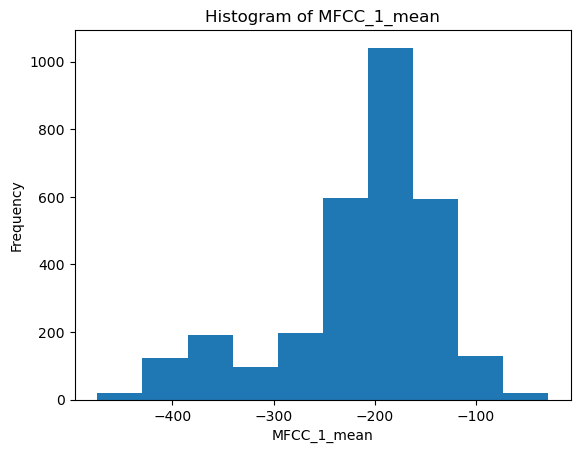

In [4]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt

def extract_mfcc_features(file_path):
    signal, sample_rate = librosa.load(file_path, sr=None)
    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=13
    )
    mfcc_mean = np.mean(mfcc, axis=1)
    mfcc_std = np.std(mfcc, axis=1)
    features = np.concatenate([mfcc_mean, mfcc_std])

    return features

train_path = r"D:\ASV_2017\baseline_CM\baseline_CM\ASVspoof2017_V2_train"

data = []
for filename in os.listdir(train_path):
    if filename.lower().endswith(".wav"):
        file_path = os.path.join(train_path, filename)
        features = extract_mfcc_features(file_path)
        data.append([filename] + features.tolist())

feature_names = []

for i in range(1, 14):
    feature_names.append(f"MFCC_{i}_mean")

for i in range(1, 14):
    feature_names.append(f"MFCC_{i}_std")

columns = ["filename"] + feature_names

df = pd.DataFrame(data, columns=columns)

feature = df["MFCC_1_mean"].to_numpy()

mean = np.mean(feature)
variance = np.var(feature)

print("Feature: MFCC_1_mean")
print("Mean:", mean)
print("Variance:", variance)

frequency, bin_edges = np.histogram(feature, bins=10)

print("\nHistogram Frequencies:")
print(frequency)
print("\nBucket Edges:")
print(bin_edges)
plt.hist(feature, bins=10)
plt.xlabel("MFCC_1_mean")
plt.ylabel("Frequency")
plt.title("Histogram of MFCC_1_mean")
plt.savefig("mfcc_hist.png")
plt.show()

In [5]:
import numpy as np
import pandas as pd

df = pd.read_excel(
    r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

data = df[["Income", "Kidhome", "Teenhome"]].copy()

data["Income"] = data["Income"].fillna(data["Income"].median())

for col in data.columns:
    minimum = data[col].min()
    maximum = data[col].max()

    data[col] = (
        data[col] - minimum
    ) / (maximum - minimum)

X = data.values

def Mean(data):
    total = 0
    for value in data:
        total += value
    return total / len(data)


def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both feature vectors must have the same dimensions.")
    distance = 0
    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p
    return distance ** (1 / p)

K = 3

centroids = X[:K].copy()

for iteration in range(100):

    clusters = []

    for point in X:
        distances = []
        for centroid in centroids:
            distance = MinkowskiDist(point, centroid, 2)
            distances.append(distance)
        cluster = np.argmin(distances)
        clusters.append(cluster)
    clusters = np.array(clusters)

    new_centroids = []

    for k in range(K):
        cluster_points = X[clusters == k]
        if len(cluster_points) > 0:
            new_centroid = Mean(cluster_points)
        else:
            new_centroid = centroids[k]
        new_centroids.append(new_centroid)
    new_centroids = np.array(new_centroids)
    if np.array_equal(centroids, new_centroids):
        print("Converged after", iteration + 1, "iterations")
        break
    centroids = new_centroids
    
print("\nFinal Centroids:")
print(centroids)
print("\nCluster Assignment:")
print(clusters)

Converged after 4 iterations

Final Centroids:
[[0.0842585  0.01624815 0.53840473]
 [0.05603161 0.52594595 0.21891892]
 [0.09604429 0.         0.        ]]

Cluster Assignment:
[2 1 2 ... 2 0 1]


# A2

In [6]:
def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError("Both feature vectors must have the same dimensions.")
    distance = 0
    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p
    return distance ** (1 / p)

assert Mean([1, 2, 3, 4, 5]) == 3
assert Mean([10, 20]) == 15
assert Mean([5]) == 5
assert Mean([1.5, 2.5, 3.5]) == 2.5

assert MinkowskiDist([0, 0], [3, 4], 2) == 5
assert MinkowskiDist([0, 0], [3, 4], 1) == 7
assert MinkowskiDist([1, 2, 3], [1, 2, 3], 2) == 0

try:
    MinkowskiDist([1, 2], [1, 2, 3], 2)
    assert False
except ValueError:
    assert True

print("All unit tests passed!")

All unit tests passed!


# A3

In [1]:
import numpy as np
import pandas as pd
import time

df = pd.read_excel(
    r"C:\Users\ivysa\OneDrive\Desktop\College Projects\ML\Lab Session Data.xlsx",
    sheet_name="marketing_campaign"
)

data = df[["Income", "Kidhome", "Teenhome"]].copy()

data["Income"] = data["Income"].fillna(data["Income"].median())

for col in data.columns:
    minimum = data[col].min()
    maximum = data[col].max()

    data[col] = (
        data[col] - minimum
    ) / (maximum - minimum)

X = data.values

def Mean(data):
    total = 0
    for value in data:
        total += value
    return total / len(data)

def MinkowskiDist(X, Y, p):
    if len(X) != len(Y):
        raise ValueError(
            "Both feature vectors must have the same dimensions."
        )
    distance = 0
    for i in range(len(X)):
        distance += abs(X[i] - Y[i]) ** p
    return distance ** (1 / p)

def my_kmeans(X, K):
    centroids = X[:K].copy()
    for iteration in range(100):
        clusters = []
        for point in X:
            distances = []
            for centroid in centroids:
                distance = MinkowskiDist(
                    point,
                    centroid,
                    2
                )
                distances.append(distance)
            cluster = np.argmin(distances)
            clusters.append(cluster)

        clusters = np.array(clusters)

        new_centroids = []

        for k in range(K):
            cluster_points = X[clusters == k]
            if len(cluster_points) > 0:
                new_centroid = Mean(cluster_points)
            else:
                new_centroid = centroids[k]
            new_centroids.append(new_centroid)
        new_centroids = np.array(new_centroids)
        if np.array_equal(
            centroids,
            new_centroids
        ):
            break
        centroids = new_centroids
    return centroids, clusters


def ai_kmeans(X, K):
    centroids = X[:K].copy()
    for iteration in range(100):
        distances = np.zeros(
            (len(X), K)
        )
        for i in range(len(X)):
            for j in range(K):
                distances[i, j] = MinkowskiDist(
                    X[i],
                    centroids[j],
                    2
                )
        clusters = np.argmin(
            distances,
            axis=1
        )
        new_centroids = np.zeros_like(
            centroids
        )
        for k in range(K):
            cluster_points = X[
                clusters == k
            ]
            if len(cluster_points) > 0:
                new_centroids[k] = Mean(
                    cluster_points
                )
            else:
                new_centroids[k] = centroids[k]
        if np.array_equal(
            centroids,
            new_centroids
        ):
            break
        centroids = new_centroids
    return centroids, clusters

K = 3

start = time.perf_counter()

my_centroids, my_clusters = my_kmeans(
    X,
    K
)

my_time = time.perf_counter() - start

start = time.perf_counter()
ai_centroids, ai_clusters = ai_kmeans(
    X,
    K
)

ai_time = time.perf_counter() - start

print("========== YOUR K-MEANS ==========")
print("\nFinal Centroids:")
print(my_centroids)
print("\nCluster Assignments:")
print(my_clusters)
print("\nExecution Time:")
print(my_time, "seconds")

print("\n\n========== AI K-MEANS ==========")
print("\nFinal Centroids:")
print(ai_centroids)
print("\nCluster Assignments:")
print(ai_clusters)
print("\nExecution Time:")
print(ai_time, "seconds")

print("\n\n========== PERFORMANCE COMPARISON ==========")
if my_time < ai_time:
    print("Your K-means is faster.")
elif ai_time < my_time:
    print("AI-generated K-means is faster.")
else:
    print("Both implementations have approximately the same execution time.")

print("\nMy K-means time :", my_time, "seconds")
print("AI K-means time   :", ai_time, "seconds")

========== YOUR K-MEANS ==========

Final Centroids:
[[0.0842585  0.01624815 0.53840473]
 [0.05603161 0.52594595 0.21891892]
 [0.09604429 0.         0.        ]]

Cluster Assignments:
[2 1 2 ... 2 0 1]

Execution Time:
0.3446544000000813 seconds


========== AI K-MEANS ==========

Final Centroids:
[[0.0842585  0.01624815 0.53840473]
 [0.05603161 0.52594595 0.21891892]
 [0.09604429 0.         0.        ]]

Cluster Assignments:
[2 1 2 ... 2 0 1]

Execution Time:
0.2939125000000331 seconds


========== PERFORMANCE COMPARISON ==========
AI-generated K-means is faster.

My K-means time : 0.3446544000000813 seconds
AI K-means time   : 0.2939125000000331 seconds
